# Deskriptivna i eksplorativna analiza (EDA) - britpop.csv

Struktura analize:

1. Osnovni pregled podataka (obim, nedostajuće vrednosti, opseg).
2. Distribucije audio karakteristika.
3. Evolucija zvuka kroz vreme.
4. Poređenje izvođača.
5. Muzički stil, raspoloženje i tematika (AllMusic).
6. Korelacije između audio karakteristika i popularnosti.
7. Tonalitet i mod.
8. AllMusic "Track Pick" - da li su kritički izdvojene pesme drugačije.
9. Trajanje pesama.

Svaki grafikon se čuva kao PNG (300 dpi) u podfolderu `grafici/`

In [1]:
!pip install pandas matplotlib seaborn --break-system-packages -q


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

BASE_DIR = Path.cwd()
INPUT_CSV = BASE_DIR / "britpop.csv"
FIG_DIR = BASE_DIR / "grafici"
FIG_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13

ACCENT = "#4C72B0"


def save_fig(fig, filename):
    path = FIG_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Sacuvano: {path.relative_to(BASE_DIR)}")
    plt.show()


print("Radni folder:", BASE_DIR)
print(f"  {'OK' if INPUT_CSV.exists() else 'NEDOSTAJE'} - {INPUT_CSV.name}")

Radni folder: C:\Users\Milica\Desktop\FON\diplomski
  OK - britpop.csv


## 1) Učitavanje i osnovni pregled podataka

In [3]:
df = pd.read_csv(INPUT_CSV, low_memory=False)

print(f"Broj pesama: {len(df)}")
print(f"Broj kolona: {df.shape[1]}")
print(f"Broj izvođača: {df['artist_name'].nunique()}")
print(f"Broj albuma: {df['album_name'].nunique()}")

full_date = df["release_date"].astype(str).str.fullmatch(r"\d{4}-\d{2}-\d{2}")
years = pd.to_datetime(df.loc[full_date, "release_date"]).dt.year
print(f"Vremenski opseg (pesme sa potpunim datumom, {full_date.sum()}/{len(df)}): {years.min()}-{years.max()}")

df.head()

Broj pesama: 1630
Broj kolona: 49
Broj izvođača: 22
Broj albuma: 160
Vremenski opseg (pesme sa potpunim datumom, 1593/1630): 1964-2025


,track_id,track_name,artist_name,album_name,song_genre,release_date,track_number,disc_number,duration_ms,duration_s,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,4Kucn8p48pDkoZdIRCOB01,Season,Ash,Trailer,Pop/Rock,1994-10-01,1,1,181040,181.04,...,0,-6.059,1,0.1090,0.000896,0.8400,0.517,0.207,171.929,4
1,0boNKrTLvgY200vkhmfkrl,Jack Names The Planets,Ash,Trailer,Pop/Rock,1994-10-01,2,1,190360,190.36,...,9,-7.034,1,0.1060,0.006470,0.2060,0.443,0.516,151.514,4
2,3dvxpgCNCgZqSqAdnSNU7n,Intense Thing,Ash,Trailer,Unknown,1994-10-01,3,1,274200,274.20,...,9,-4.714,0,0.0549,0.000661,0.8860,0.362,0.364,98.908,4
3,1o5gIYys3cw11Ryur8GrND,Uncle Pat,Ash,Trailer,Pop/Rock,1994-10-01,4,1,192133,192.13,...,9,-5.216,1,0.0331,0.032000,0.0411,0.249,0.780,98.929,4
4,37LhwN5oJmvVmhBpl4MpSA,Get Out,Ash,Trailer,Pop/Rock,1994-10-01,5,1,103200,103.20,...,11,-4.658,0,0.1880,0.351000,0.1890,0.716,0.107,155.621,4


In [4]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Kolone sa nedostajućim vrednostima (NaN):")
print(missing)
print()
print("Napomena: mnoga AllMusic tekstualna polja (npr. song_style, song_mood, song_theme,")
print("composers, recording_location) koriste vrednost 'Unknown' umesto NaN kada AllMusic")
print("nije objavio taj podatak za pesmu/album - to se NE vidi u tabeli iznad. Broj takvih")
print("vrednosti po koloni:")
unknown_counts = (df.select_dtypes(include="object") == "Unknown").sum()
print(unknown_counts[unknown_counts > 0].sort_values(ascending=False))

Kolone sa nedostajućim vrednostima (NaN):
artist_lifespan_end      1410
album_duration_sec         45
artist_lifespan_begin       5
artist_is_active            5
dtype: int64

Napomena: mnoga AllMusic tekstualna polja (npr. song_style, song_mood, song_theme,
composers, recording_location) koriste vrednost 'Unknown' umesto NaN kada AllMusic
nije objavio taj podatak za pesmu/album - to se NE vidi u tabeli iznad. Broj takvih
vrednosti po koloni:
song_theme            1018
song_mood              845
song_genre             844
song_style             843
musicbrainz_tags       725
recording_location     559
album_theme            298
composers              188
release_country        169
label                  137
album_mood             104
album_duration          45
artist_country          10
album_style              3
dtype: int64


C:\Users\Milica\AppData\Local\Temp\ipykernel_14188\3069712915.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  unknown_counts = (df.select_dtypes(include="object") == "Unknown").sum()


### Broj pesama po izvođaču u datasetu

Bitno je imati na umu da dataset nije ravnomerno raspoređen po izvođačima -
neki (npr. Paul Weller, Manic Street Preachers) imaju mnogo duže/plodnije
karijere obuhvaćene datasetom nego drugi, što treba uzeti u obzir pri
tumačenju svih narednih poređenja između izvođača.

Sacuvano: grafici\01_broj_pesama_po_izvodjacu.png


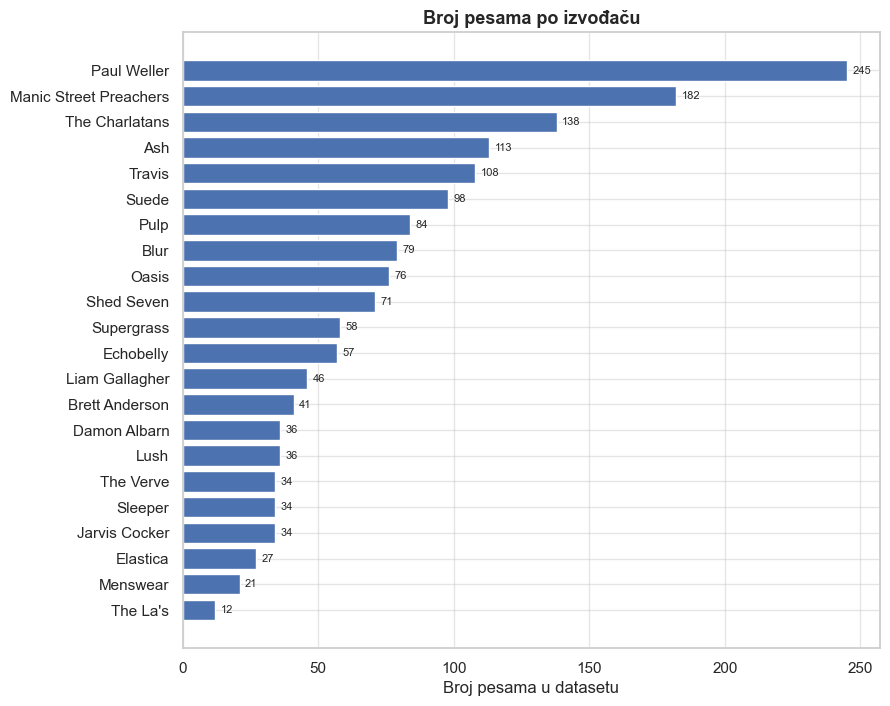

In [5]:
counts = df["artist_name"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(counts.index, counts.values, color=ACCENT)
ax.set_xlabel("Broj pesama u datasetu")
ax.set_ylabel("")
ax.set_title("Broj pesama po izvođaču")
for i, v in enumerate(counts.values):
    ax.text(v + 2, i, str(v), va="center", fontsize=8)

save_fig(fig, "01_broj_pesama_po_izvodjacu.png")

## 2) Distribucije audio karakteristika

### Broj izdatih pesama po godini

Prikazane su samo pesme sa potpunim datumom izdanja (`release_date` u
formatu yyyy-mm-dd).

Sacuvano: grafici\02_pesme_po_godinama.png


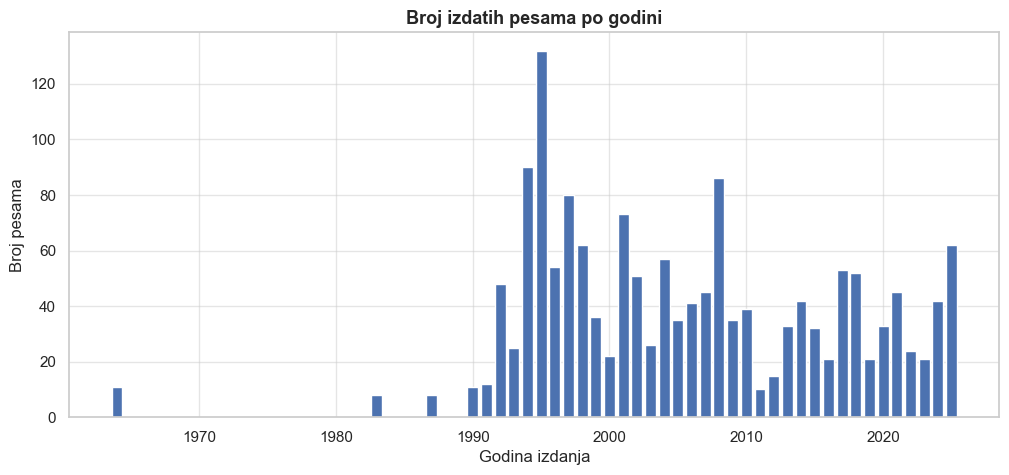

In [6]:
year_counts = years.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(year_counts.index, year_counts.values, color=ACCENT, width=0.8)
ax.set_xlabel("Godina izdanja")
ax.set_ylabel("Broj pesama")
ax.set_title("Broj izdatih pesama po godini")

save_fig(fig, "02_pesme_po_godinama.png")

### Distribucije Spotify audio karakteristika

Spotify audio karakteristike su numeričke ocene koje opisuju zvučni
karakter svake pesme.

Sacuvano: grafici\03_distribucije_audio_karakteristika.png


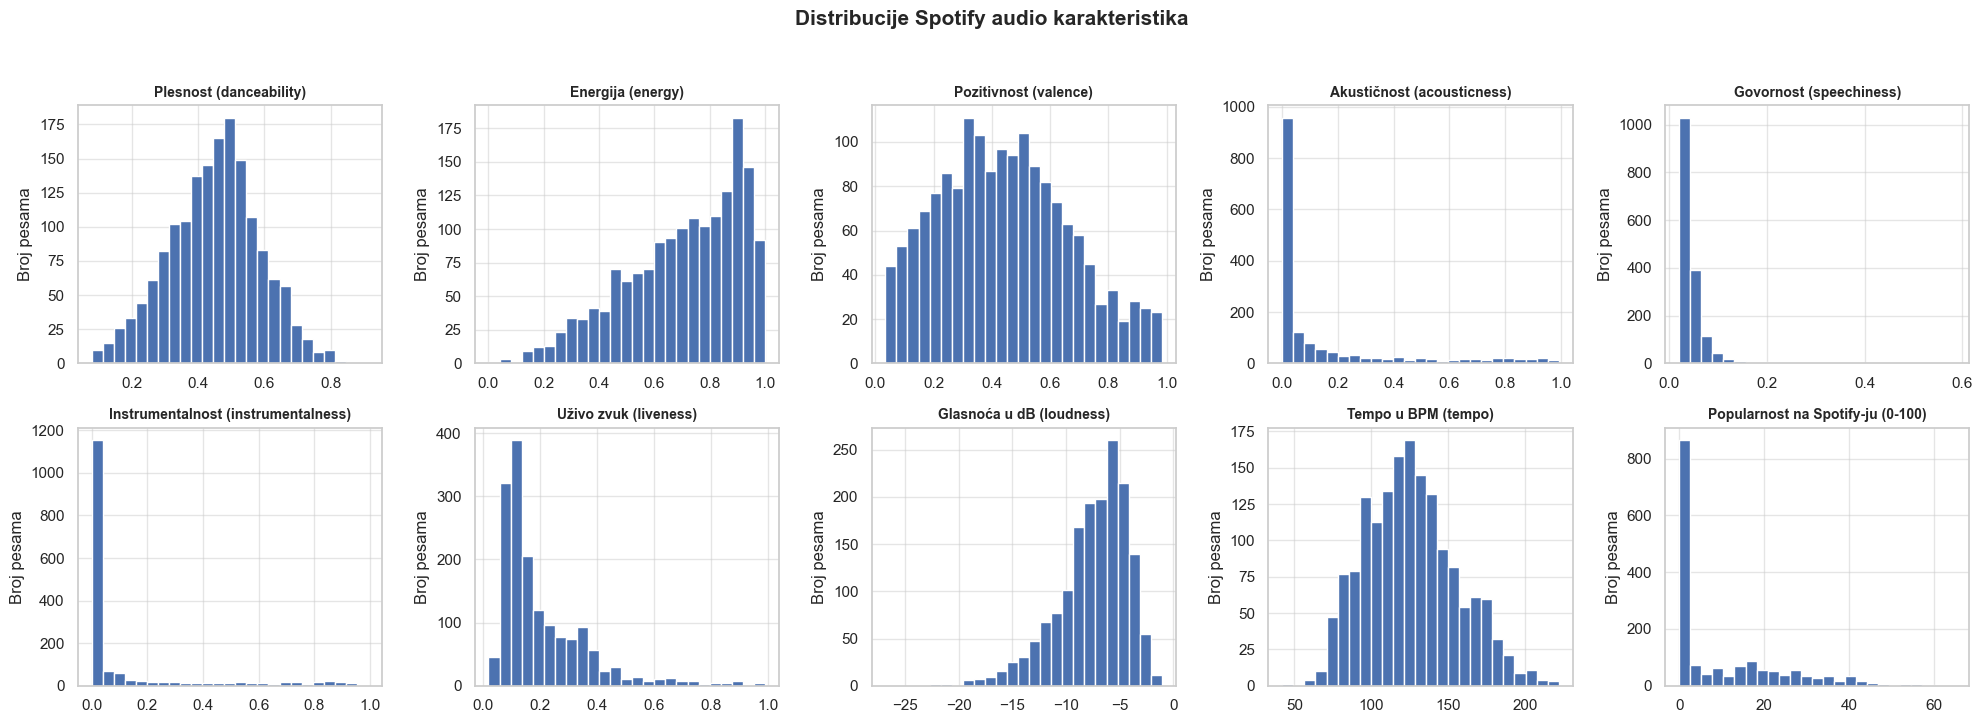

In [7]:
FEATURES = [
    ("danceability", "Plesnost (danceability)"),
    ("energy", "Energija (energy)"),
    ("valence", "Pozitivnost (valence)"),
    ("acousticness", "Akustičnost (acousticness)"),
    ("speechiness", "Govornost (speechiness)"),
    ("instrumentalness", "Instrumentalnost (instrumentalness)"),
    ("liveness", "Uživo zvuk (liveness)"),
    ("loudness", "Glasnoća u dB (loudness)"),
    ("tempo", "Tempo u BPM (tempo)"),
    ("popularity", "Popularnost na Spotify-ju (0-100)"),
]

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, (col, label) in zip(axes.flat, FEATURES):
    ax.hist(df[col].dropna(), bins=25, color=ACCENT, edgecolor="white")
    ax.set_title(label, fontsize=10)
    ax.set_ylabel("Broj pesama")

fig.suptitle("Distribucije Spotify audio karakteristika", fontsize=15, fontweight="bold", y=1.03)
fig.tight_layout()

save_fig(fig, "03_distribucije_audio_karakteristika.png")

In [8]:
print("Deskriptivna statistika audio karakteristika:")
df[[c for c, _ in FEATURES] + ["danceability", "duration_s"]].describe().T

Deskriptivna statistika audio karakteristika:


,count,mean,std,min,25%,50%,75%,max
danceability,1630.0,0.449158,0.137609,0.07790,0.358000,0.456000,0.540000,0.913
energy,1630.0,0.701469,0.208075,0.00075,0.560000,0.735000,0.882000,0.999
valence,1630.0,0.443092,0.224202,0.03420,0.268250,0.432000,0.596750,0.983
acousticness,1630.0,0.148801,0.253510,0.00000,0.000741,0.015450,0.163250,0.992
speechiness,1630.0,0.046317,0.030971,0.02000,0.030025,0.037500,0.050275,0.586
instrumentalness,1630.0,0.118622,0.238888,0.00000,0.000025,0.001905,0.076425,0.993
liveness,1630.0,0.207677,0.160799,0.02000,0.101000,0.143000,0.274750,0.988
loudness,1630.0,-7.518750,3.350367,-26.85700,-9.204500,-6.912500,-5.081000,-1.059
tempo,1630.0,125.933110,29.876432,42.12200,103.292750,124.380000,144.589250,221.947
popularity,1630.0,10.061963,13.630094,0.00000,0.000000,1.000000,18.000000,65.000


## 3) Evolucija zvuka kroz vreme

Prosečne vrednosti ključnih audio karakteristika po deceniji izdanja.

Sacuvano: grafici\04_trend_audio_karakteristika_kroz_vreme.png


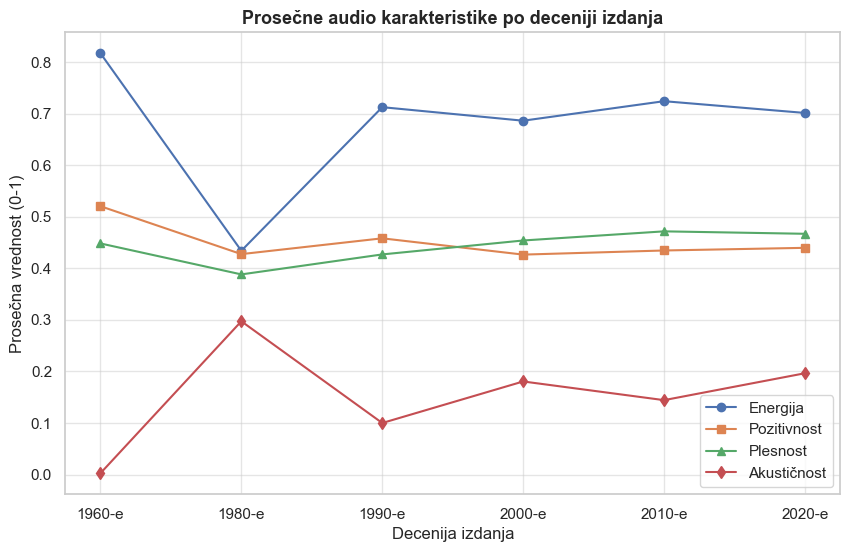


Broj pesama po deceniji:
_decade
1960.0     11
1980.0     16
1990.0    550
2000.0    471
2010.0    318
2020.0    227
dtype: int64


In [9]:
df["_year"] = pd.NA
df.loc[full_date, "_year"] = years.values
df["_decade"] = (pd.to_numeric(df["_year"], errors="coerce") // 10 * 10)

decade_stats = (
    df.dropna(subset=["_decade"])
    .groupby("_decade")[["energy", "valence", "danceability", "acousticness"]]
    .mean()
)
decade_counts = df.dropna(subset=["_decade"]).groupby("_decade").size()

fig, ax = plt.subplots(figsize=(10, 6))
for col, label, marker in [
    ("energy", "Energija", "o"),
    ("valence", "Pozitivnost", "s"),
    ("danceability", "Plesnost", "^"),
    ("acousticness", "Akustičnost", "d"),
]:
    ax.plot(decade_stats.index.astype(int).astype(str) + "-e", decade_stats[col], marker=marker, label=label)

ax.set_xlabel("Decenija izdanja")
ax.set_ylabel("Prosečna vrednost (0-1)")
ax.set_title("Prosečne audio karakteristike po deceniji izdanja")
ax.legend()

save_fig(fig, "04_trend_audio_karakteristika_kroz_vreme.png")
print("\nBroj pesama po deceniji:")
print(decade_counts)

## 4) Poređenje izvođača

Energija i pozitivnost (valence) po izvođaču, sortirano po medijani -
pokazuje razlike u "zvučnom karakteru" između izvođača u datasetu.

Sacuvano: grafici\05_audio_karakteristike_po_izvodjacu.png


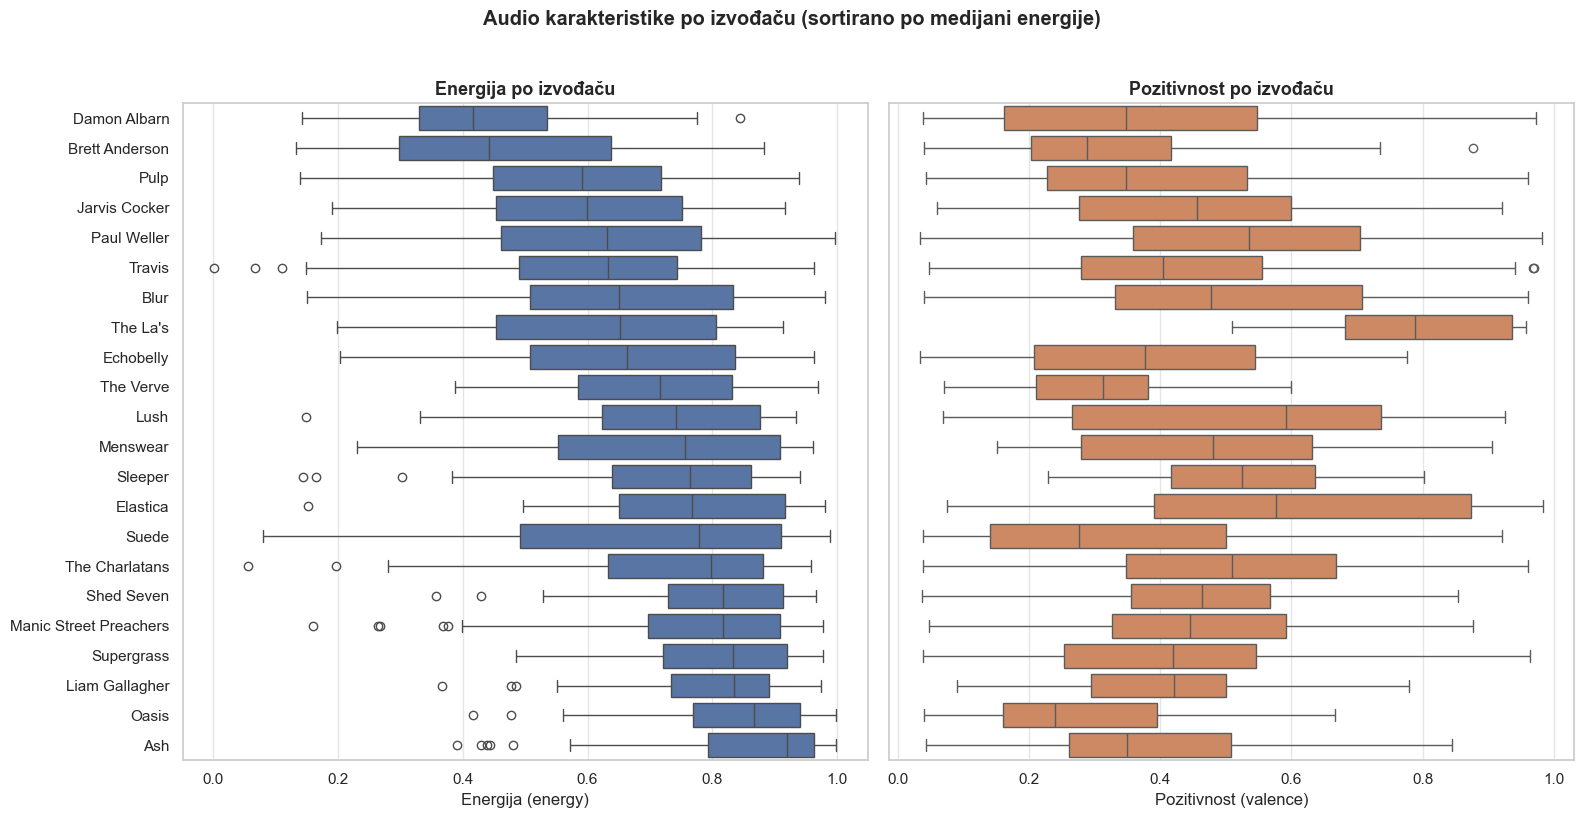

In [10]:
order_energy = df.groupby("artist_name")["energy"].median().sort_values().index

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

sns.boxplot(data=df, y="artist_name", x="energy", order=order_energy, color=ACCENT, ax=axes[0])
axes[0].set_title("Energija po izvođaču")
axes[0].set_xlabel("Energija (energy)")
axes[0].set_ylabel("")

sns.boxplot(data=df, y="artist_name", x="valence", order=order_energy, color="#DD8452", ax=axes[1])
axes[1].set_title("Pozitivnost po izvođaču")
axes[1].set_xlabel("Pozitivnost (valence)")
axes[1].set_ylabel("")

fig.suptitle("Audio karakteristike po izvođaču (sortirano po medijani energije)", fontweight="bold", y=1.02)
fig.tight_layout()

save_fig(fig, "05_audio_karakteristike_po_izvodjacu.png")

### Prosečna popularnost po izvođaču

Sacuvano: grafici\06_popularnost_po_izvodjacu.png


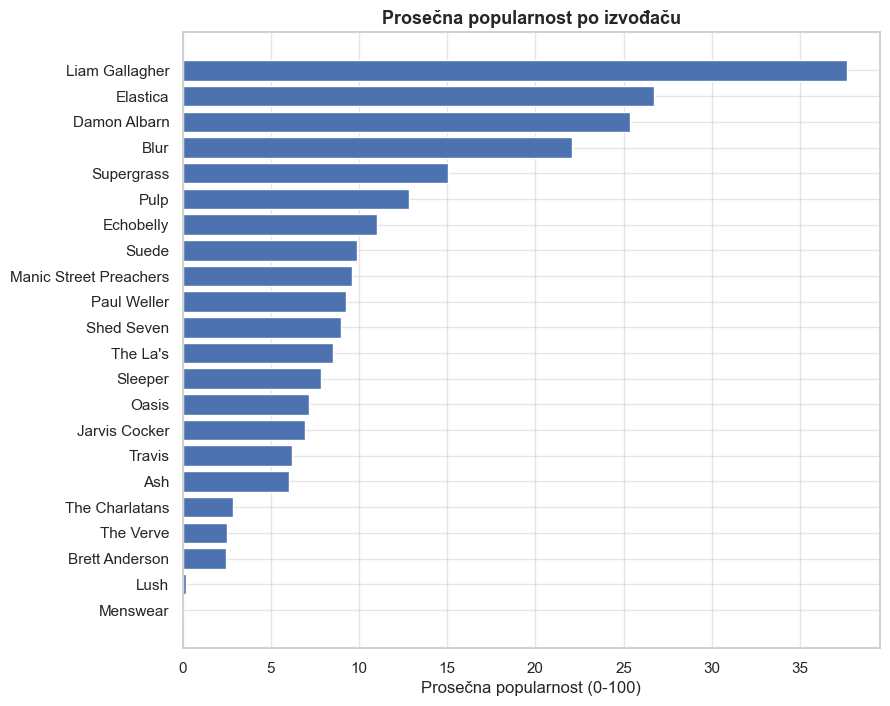

In [11]:
pop_by_artist = df.groupby("artist_name")["popularity"].mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(pop_by_artist.index, pop_by_artist.values, color=ACCENT)
ax.set_xlabel("Prosečna popularnost (0-100)")
ax.set_title("Prosečna popularnost po izvođaču")

save_fig(fig, "06_popularnost_po_izvodjacu.png")

## 5) Muzički stil, raspoloženje i tematika (AllMusic)

Polja `song_style`, `song_mood` i `song_theme` sadrže više vrednosti
odvojenih zarezom (npr. "Britpop, Indie Pop, Alternative Pop/Rock"), pa se
prvo razdvajaju na pojedinačne oznake. Vrednost "Unknown" (AllMusic nije
označio tu pesmu) se ne računa.

Pesama sa poznatim song_style: 787 / 1630
Sacuvano: grafici\07_top_muzicki_stilovi.png


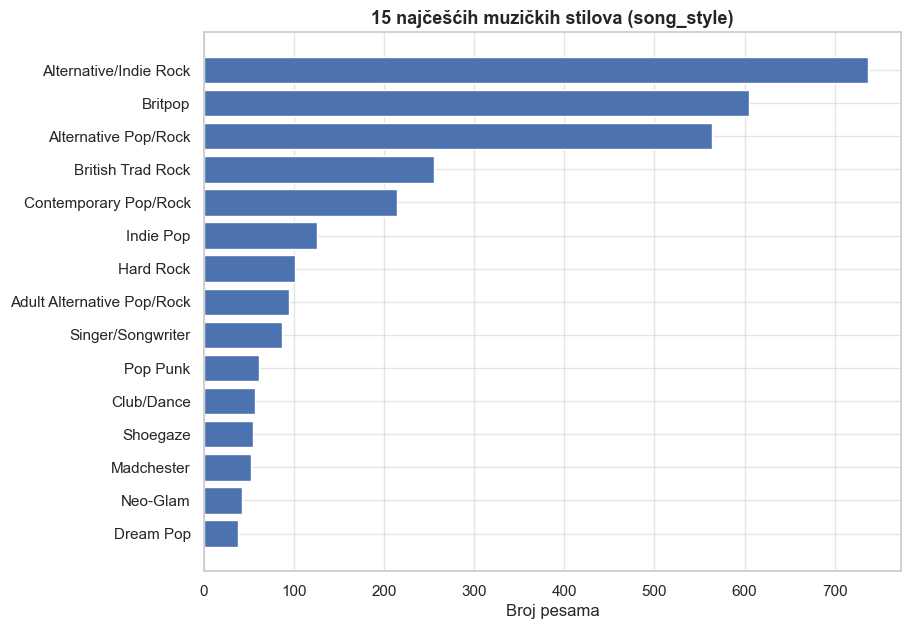

In [12]:
def top_split_values(column, n=15):
    values = df[column].dropna()
    values = values[values != "Unknown"]
    exploded = values.str.split(",").explode().str.strip()
    return exploded.value_counts().head(n)


top_style = top_split_values("song_style")
known_style = (df["song_style"] != "Unknown").sum()
print(f"Pesama sa poznatim song_style: {known_style} / {len(df)}")

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_style.index[::-1], top_style.values[::-1], color=ACCENT)
ax.set_xlabel("Broj pesama")
ax.set_title("15 najčešćih muzičkih stilova (song_style)")

save_fig(fig, "07_top_muzicki_stilovi.png")

Sacuvano: grafici\08_top_raspolozenja_i_teme.png


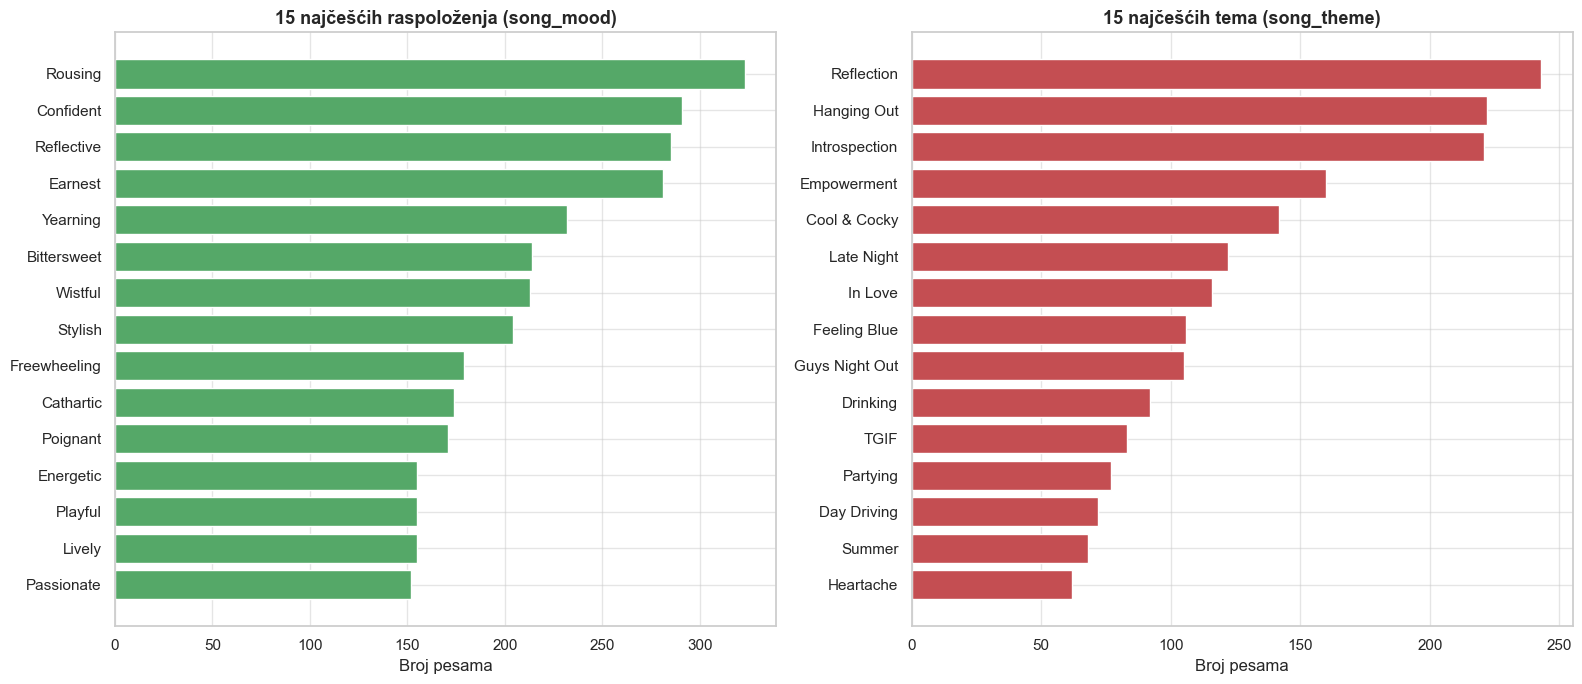

In [13]:
top_mood = top_split_values("song_mood")
top_theme = top_split_values("song_theme")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(top_mood.index[::-1], top_mood.values[::-1], color="#55A868")
axes[0].set_title("15 najčešćih raspoloženja (song_mood)")
axes[0].set_xlabel("Broj pesama")

axes[1].barh(top_theme.index[::-1], top_theme.values[::-1], color="#C44E52")
axes[1].set_title("15 najčešćih tema (song_theme)")
axes[1].set_xlabel("Broj pesama")

fig.tight_layout()
save_fig(fig, "08_top_raspolozenja_i_teme.png")

## 6) Korelacije između audio karakteristika i popularnosti

Sacuvano: grafici\09_korelaciona_matrica.png


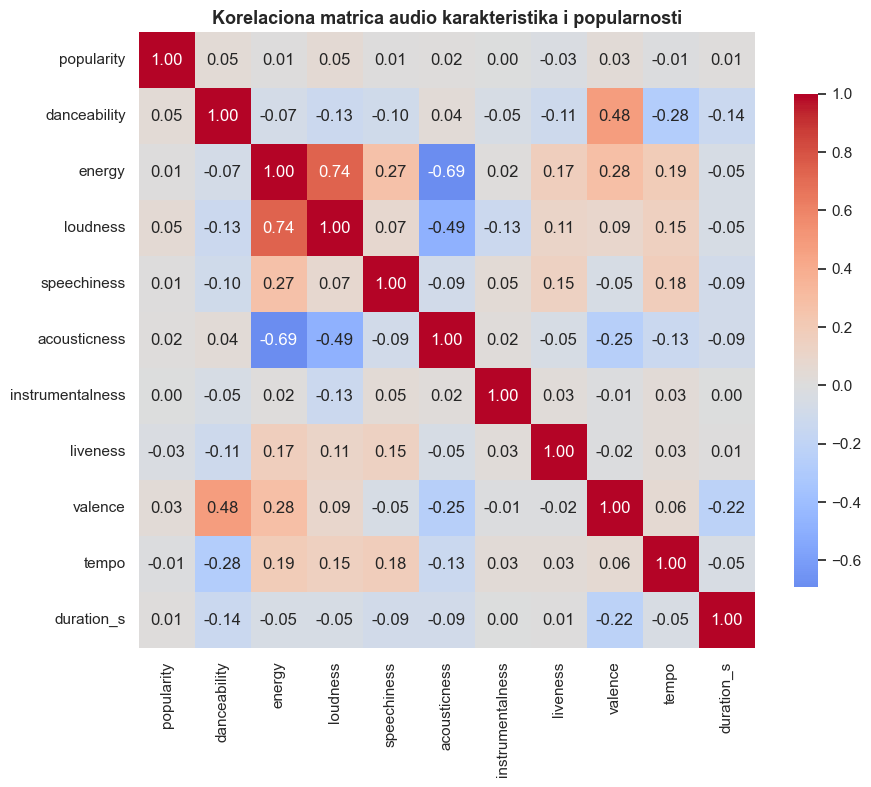

In [14]:
corr_cols = [
    "popularity", "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence", "tempo",
    "duration_s",
]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Korelaciona matrica audio karakteristika i popularnosti")

save_fig(fig, "09_korelaciona_matrica.png")

## 7) Tonalitet i mod

`key` je tonalitet pesme, a `mode` govori da
li je pesma u dur (1) ili mol (0) tonalitetu.

Sacuvano: grafici\10_tonalitet_i_mod.png


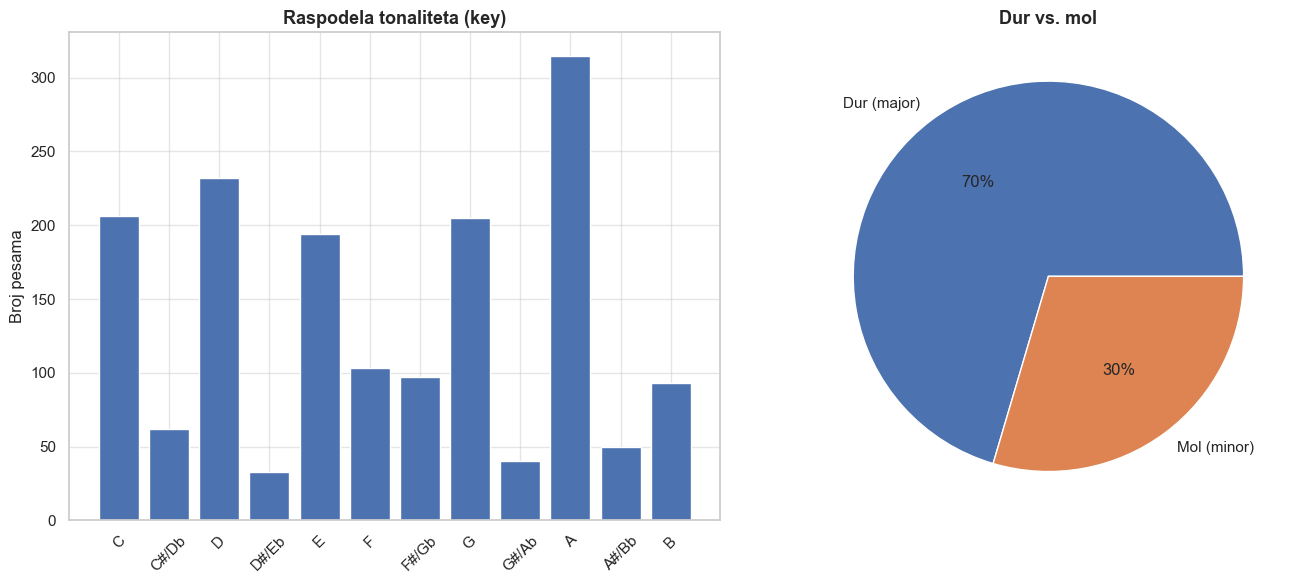

In [15]:
KEY_NAMES = ["C", "C#/Db", "D", "D#/Eb", "E", "F", "F#/Gb", "G", "G#/Ab", "A", "A#/Bb", "B"]

key_counts = df["key"].value_counts().reindex(range(12), fill_value=0)
mode_counts = df["mode"].map({1: "Dur (major)", 0: "Mol (minor)"}).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar([KEY_NAMES[i] for i in key_counts.index], key_counts.values, color=ACCENT)
axes[0].set_title("Raspodela tonaliteta (key)")
axes[0].set_ylabel("Broj pesama")
axes[0].tick_params(axis="x", rotation=45)

axes[1].pie(mode_counts.values, labels=mode_counts.index, autopct="%1.0f%%", colors=["#4C72B0", "#DD8452"])
axes[1].set_title("Dur vs. mol")

fig.tight_layout()
save_fig(fig, "10_tonalitet_i_mod.png")

## 8) AllMusic "Track Pick" - da li su kritički izdvojene pesme drugačije?

AllMusic urednici na svakom albumu izdvajaju određene pesme kao "Track
Pick" (preporučene/istaknute pesme). Zanimljivo je proveriti da li se te
pesme razlikuju od ostalih po popularnosti na Spotify-ju ili po audio
karakteristikama.

Sacuvano: grafici\11_track_pick_poredjenje.png


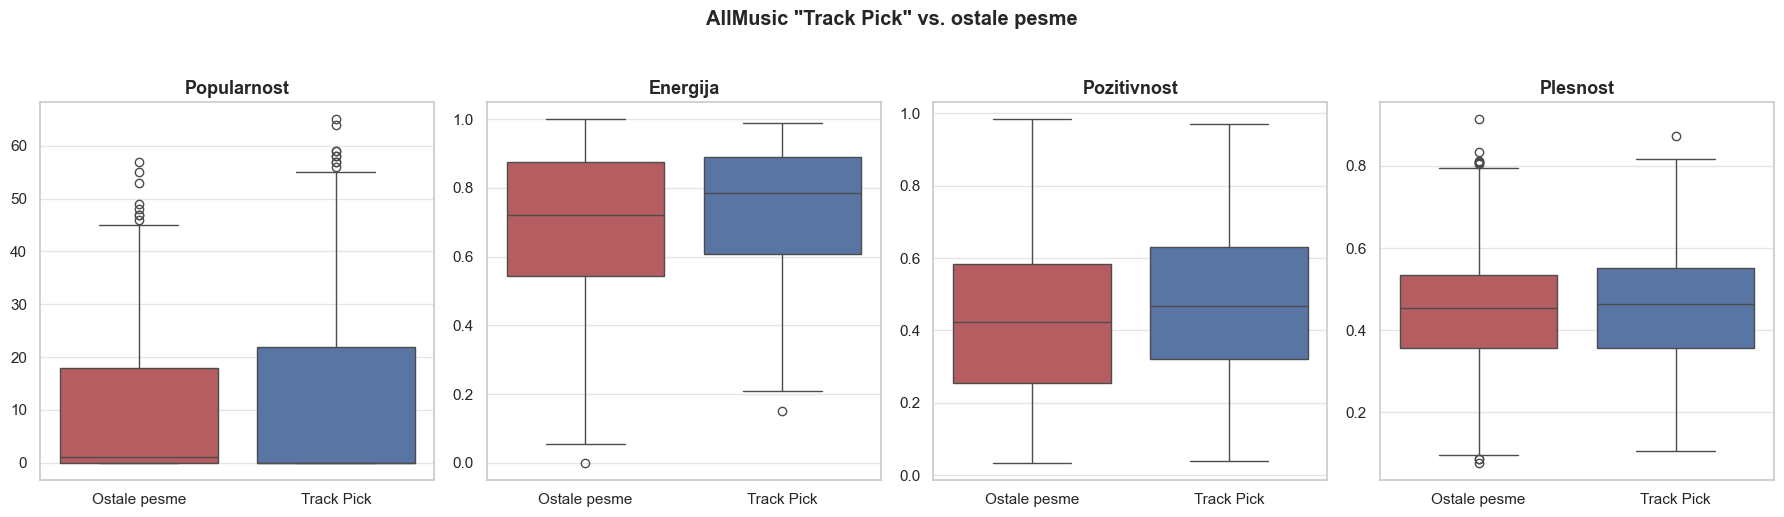

                     popularity    energy   valence  danceability
allmusic_track_pick                                              
False                  9.520919  0.688009  0.430417      0.446561
True                  11.666667  0.741392  0.480686      0.456861


In [16]:
pick_label = df["allmusic_track_pick"].map({True: "Track Pick", False: "Ostale pesme"})

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, col, label in zip(
    axes,
    ["popularity", "energy", "valence", "danceability"],
    ["Popularnost", "Energija", "Pozitivnost", "Plesnost"],
):
    sns.boxplot(x=pick_label, y=df[col], hue=pick_label, palette=["#C44E52", "#4C72B0"], legend=False, ax=ax)
    ax.set_title(label)
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.suptitle('AllMusic "Track Pick" vs. ostale pesme', fontweight="bold", y=1.03)
fig.tight_layout()

save_fig(fig, "11_track_pick_poredjenje.png")
print(df.groupby("allmusic_track_pick")[["popularity", "energy", "valence", "danceability"]].mean())

## 9) Trajanje pesama

Sacuvano: grafici\12_trajanje_pesama.png


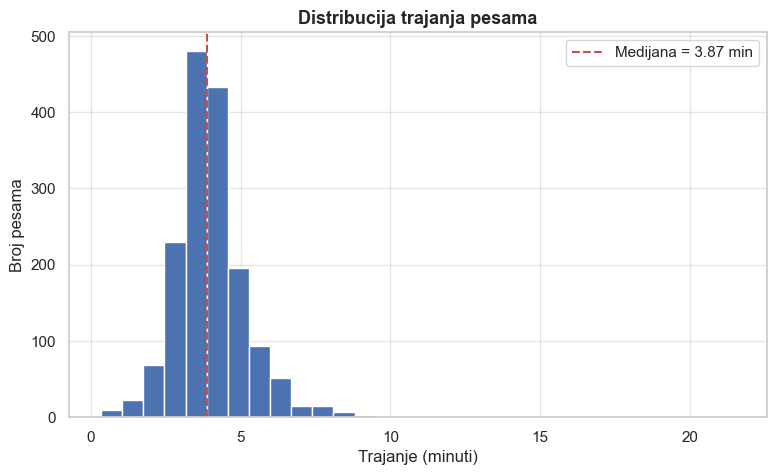

count    1630.000000
mean        4.012867
std         1.298258
min         0.340833
25%         3.315000
50%         3.869667
75%         4.518208
max        21.505167
Name: duration_s, dtype: float64


In [17]:
duration_min = df["duration_s"] / 60

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(duration_min, bins=30, color=ACCENT, edgecolor="white")
ax.axvline(duration_min.median(), color="#C44E52", linestyle="--", label=f"Medijana = {duration_min.median():.2f} min")
ax.set_xlabel("Trajanje (minuti)")
ax.set_ylabel("Broj pesama")
ax.set_title("Distribucija trajanja pesama")
ax.legend()

save_fig(fig, "12_trajanje_pesama.png")
print(duration_min.describe())

## Pregled sačuvanih grafikona

Svi grafikoni su sačuvani u podfolderu `grafici/` (300 dpi, PNG):

1. `01_broj_pesama_po_izvodjacu.png`
2. `02_pesme_po_godinama.png`
3. `03_distribucije_audio_karakteristika.png`
4. `04_trend_audio_karakteristika_kroz_vreme.png`
5. `05_audio_karakteristike_po_izvodjacu.png`
6. `06_popularnost_po_izvodjacu.png`
7. `07_top_muzicki_stilovi.png`
8. `08_top_raspolozenja_i_teme.png`
9. `09_korelaciona_matrica.png`
10. `10_tonalitet_i_mod.png`
11. `11_track_pick_poredjenje.png`
12. `12_trajanje_pesama.png`

Spremni su za direktno ubacivanje u tekst diplomskog rada.